In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.inspection import permutation_importance
import joblib

In [ ]:
df = pd.read_csv("dataset/tips.csv")

In [ ]:
print("===== 데이터 정보 =====")
print(df.info())
print(df.describe())

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill    tip   size
count      244.00 244.00 244.00
mean        19.79   3.00   2.57
std          8.90   1.38   0.95
min          3.07   1.00   1.00
25%         13.35   2.00   2.00
50%         17.80   2.90   2.00
75%         24.13   3.56   3.00
max         50.81  10.00   6.00


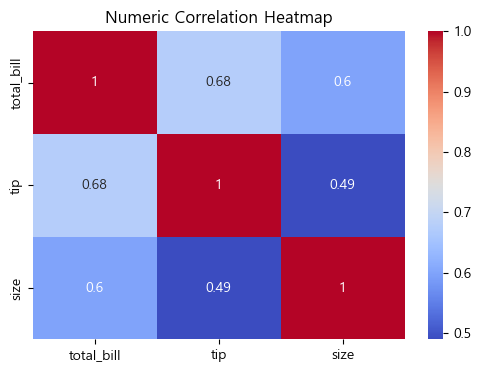

In [ ]:
# 2. EDA - 수치형 히트맵
plt.figure(figsize=(6,4))
corr = df[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Numeric Correlation Heatmap")
plt.show()

In [ ]:
# 3. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [ ]:
# 4. Feature / Target 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [ ]:
# 5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 6. 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# 7. 예측
y_pred = model.predict(X_test)

In [ ]:
# 8. 성능 평가
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


R2 Score: 0.2299
RMSE: 0.9811


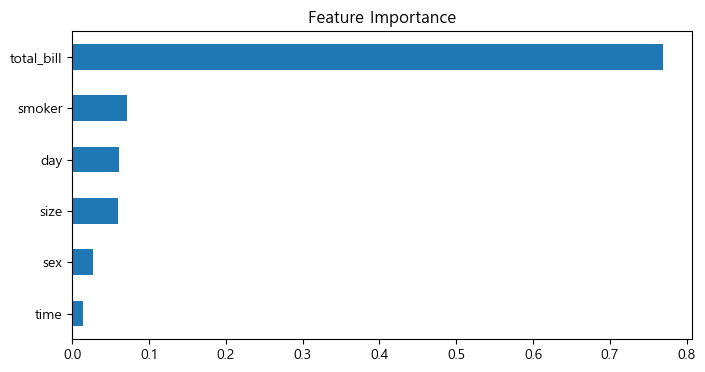

In [ ]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,4))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

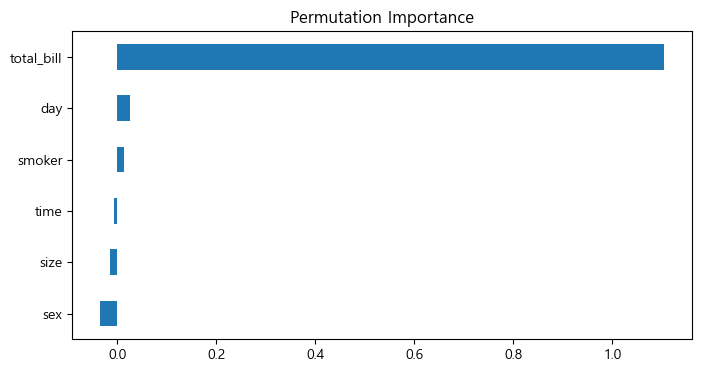

In [ ]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,4))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [ ]:
# 11. 모델 저장
joblib.dump(model, "model/tips_model01.pkl")
joblib.dump(encoders, "model/tips_labelencoders01.pkl")

print("\n모델 저장 완료!")


모델 저장 완료!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import joblib

In [ ]:
# 1. 데이터 로드
df = pd.read_csv("dataset/tips.csv")

print("===== 데이터 정보 =====")
print(df.info())

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [ ]:
# 2. Feature Engineering (추가된 피처, 파생변수 : 기존에 없던 정보를 새로 만들어 모델 성는을 높이는 작업)
df['bill_per_person'] = df['total_bill'] / df['size']   # 1인당 금액
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)  # 주말 여부  (True:1, False:0)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)  # 저녁 여부 (True:1, False:0)
df['tip_rate'] = df['tip'] / df['total_bill']  # 팁 비율

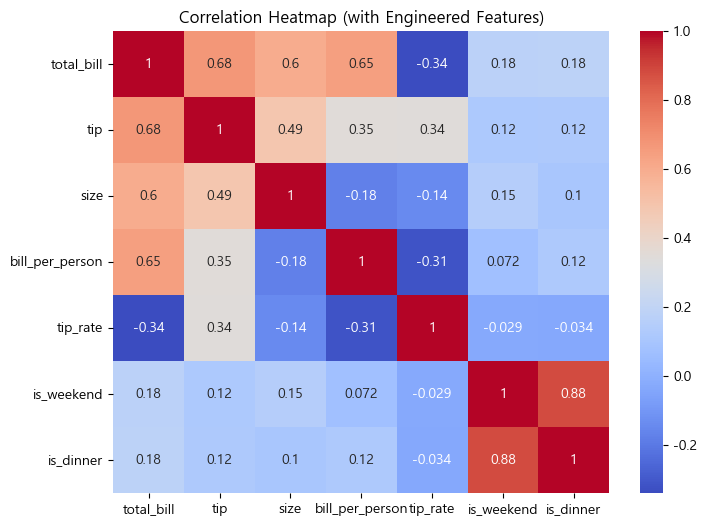

In [ ]:
# 3. 히트맵 분석 (수치형 + 파생변수 포함)
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (with Engineered Features)")
plt.show()

In [ ]:
# 4. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [ ]:
# 5. Feature/Target X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [ ]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 7. 모델 학습 (하이퍼파라미터 튜닝 적용)
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# 8. 예측 및 평가
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


===== 모델 성능 =====
R2 Score: 0.8222
RMSE: 0.4714


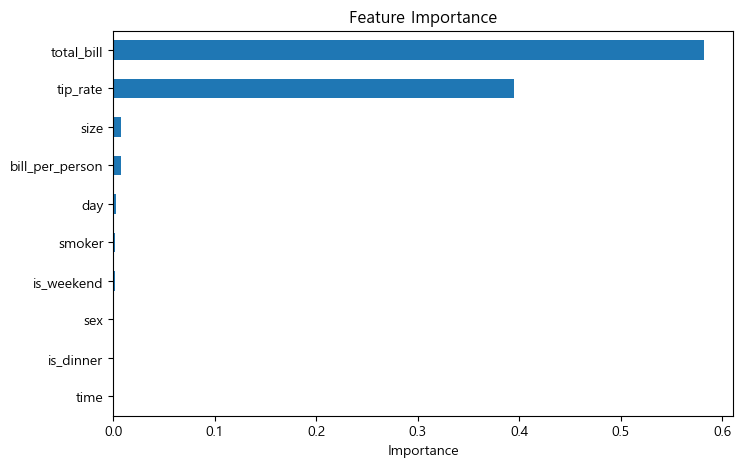

In [ ]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

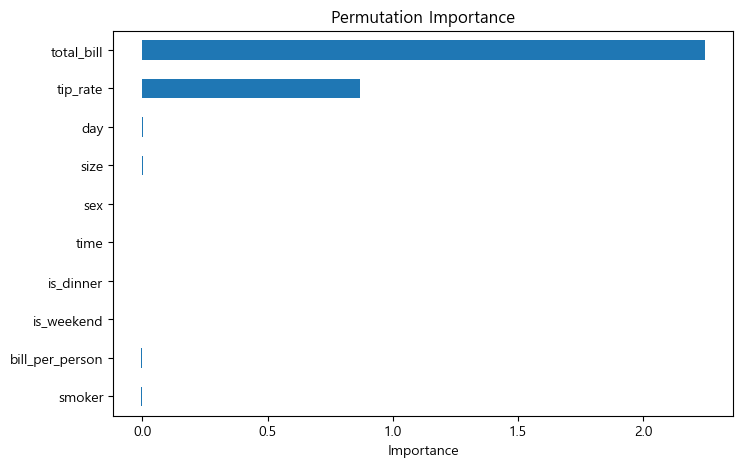

In [ ]:
# 10. Permutation Importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
# 11. 모델 저장
joblib.dump(model, "model/tips_model02.pkl")
joblib.dump(encoders, "model/tips_labelencoders02.pkl")

['model/tips_labelencoders02.pkl']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 데이터 로드
data = pd.read_csv('dataset/HousingData.csv')

In [ ]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3,222,18.70,396.90,NaN,36.20


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
print(data.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [ ]:
data = data.dropna() 

In [ ]:
print(data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
# 주요 변수 선택
X = data[['CRIM', 'RM', 'TAX', 'LSTAT']]  # 입력 변수: CRIM(범죄율), RM(방개수), TAX(세금), LSTAT(하위계층비율)
y = data['MEDV']  # 타겟 변수 (집값)

In [ ]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 모델 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 41.01145441904804
R2 Score: 0.5137736507938266


In [ ]:
# 회귀 계수 출력
print('회귀 계수:', model.coef_)
print('절편:', model.intercept_)

회귀 계수: [-0.08498347  5.59693339 -0.00824347 -0.42511164]
절편: -3.831014747888208


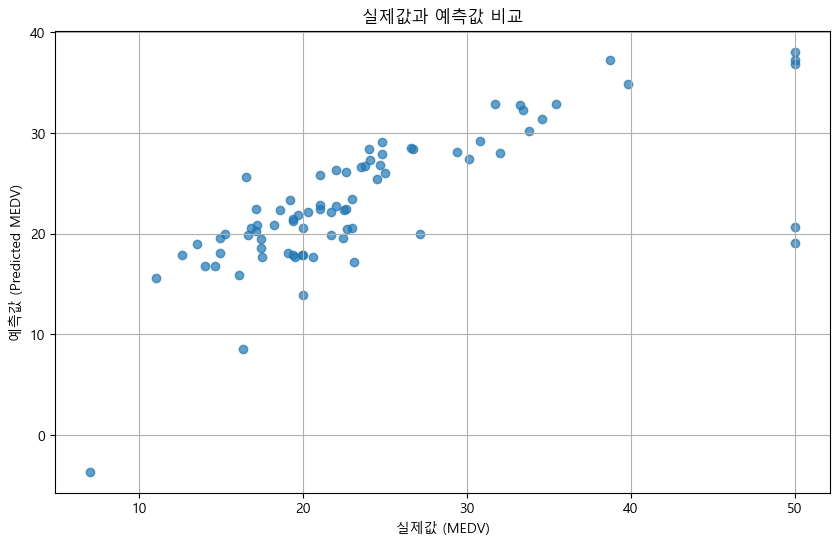

In [ ]:
# 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('실제값 (MEDV)')
plt.ylabel('예측값 (Predicted MEDV)')
plt.title('실제값과 예측값 비교')
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import streamlit as st
import matplotlib as plt

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 1. 데이터 로드 및 전처리
data = pd.read_csv('dataset/diabetes.csv')

In [ ]:
# 선택된 feature만 사용
selected_features = ['Glucose', 'BMI', 'Age']
X = data[selected_features]
y = data['Outcome']  # 예측할 대상

In [ ]:
# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2. 랜덤포레스트 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# 모델 저장
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [ ]:
# 테스트 데이터로 정확도 확인
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 73.38%


In [ ]:
# 3. Streamlit 앱
st.title('당뇨병 예측 시스템')
st.write('Glucose, BMI, Age 값을 입력하여 당뇨병 예측을 해보세요.')


2026-04-02 10:20:28.149 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.585 
  command:

    streamlit run c:\Python310\projects\ydataprofiling\.venv\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-02 10:20:29.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# 사용자 입력받기
glucose = st.slider('Glucose (혈당 수치)', min_value=0, max_value=200, value=100)
bmi = st.slider('BMI (체질량지수)', min_value=0.0, max_value=50.0, value=25.0, step=0.1)
age = st.slider('Age (나이)', min_value=0, max_value=100, value=30)

2026-04-02 10:20:29.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
# 예측하기 버튼
if st.button('예측하기'):
    # 입력값을 모델에 전달
    model = joblib.load('diabetes_model.pkl')
    input_data = np.array([[glucose, bmi, age]])
    prediction = model.predict(input_data)[0]

    # 결과 출력
    if prediction == 1:
        st.write('예측 결과: 당뇨병 가능성이 높습니다.')
    else:
        st.write('예측 결과: 당뇨병 가능성이 낮습니다.')

2026-04-02 10:20:29.973 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:29.992 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:30.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:30.015 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:20:30.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 데이터 로드
file_path = "dataset/seoul_pm10.csv"  # 데이터 파일 경로
df = pd.read_csv(file_path, encoding='cp949')
print("데이터 크기:", df.shape)
print("\n처음 5개 행:")
display(df.head())

데이터 크기: (227759, 4)

처음 5개 행:


,date,area,pm10,pm2.5
0,2022-12-31 23:00,강남구,57.00,44.00
1,2022-12-31 23:00,강동구,68.00,55.00
2,2022-12-31 23:00,강북구,59.00,42.00
3,2022-12-31 23:00,강서구,62.00,40.00
4,2022-12-31 23:00,관악구,57.00,38.00


In [ ]:
# 기본 데이터 정보 확인
print("\n데이터 기간:", df['date'].min(), "~", df['date'].max())
print("총 관측 수:", len(df))
print("지역 수:", df['area'].nunique())


데이터 기간: 2022-01-01 0:00 ~ 2022-12-31 9:00
총 관측 수: 227759
지역 수: 26


In [ ]:
# 결측치 개수 출력 수정 (ll() -> df.isnull())
print("\n결측치 개수:")
print(df.isnull().sum())


결측치 개수:
date        0
area        0
pm10     4916
pm2.5    4247
dtype: int64


In [ ]:
# 데이터 전처리
# 날짜 변환
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# 결측치 처리
df['pm10'] = df['pm10'].fillna(df['pm10'].mean())
df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].mean())

In [ ]:
# 시간 관련 피처 추가
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

In [ ]:
# 지역 원-핫 인코딩
df_encoded = pd.get_dummies(df, columns=['area'], prefix='area')

In [ ]:
# 전처리된 데이터 확인
print("\n전처리된 데이터 샘플:")
display(df_encoded.head())


전처리된 데이터 샘플:


,date,pm10,pm2.5,hour,day_of_week,month,area_강남구,area_강동구,area_강북구,area_강서구,...,area_성북구,area_송파구,area_양천구,area_영등포구,area_용산구,area_은평구,area_종로구,area_중구,area_중랑구,area_평균
0,2022-12-31 23:00:00,57.00,44.00,23,5,12,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2022-12-31 23:00:00,68.00,55.00,23,5,12,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022-12-31 23:00:00,59.00,42.00,23,5,12,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2022-12-31 23:00:00,62.00,40.00,23,5,12,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2022-12-31 23:00:00,57.00,38.00,23,5,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# PM10 모델 학습
features_pm10 = ['pm2.5', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm10 = df_encoded[features_pm10]
y_pm10 = df_encoded['pm10']


In [ ]:
# PM2.5 모델 학습
features_pm25 = ['pm10', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm25 = df_encoded[features_pm25]
y_pm25 = df_encoded['pm2.5']

In [ ]:
# 데이터 분할
X_train_pm10, X_test_pm10, y_train_pm10, y_test_pm10 = train_test_split(X_pm10, y_pm10, test_size=0.2, random_state=42)
X_train_pm25, X_test_pm25, y_train_pm25, y_test_pm25 = train_test_split(X_pm25, y_pm25, test_size=0.2, random_state=42)

In [ ]:
# 모델 학습 (RandomForestRegressor 사용)
model_pm10 = RandomForestRegressor(n_estimators=100, random_state=42)
model_pm25 = RandomForestRegressor(n_estimators=100, random_state=42)
model_pm10.fit(X_train_pm10, y_train_pm10)
model_pm25.fit(X_train_pm25, y_train_pm25)

In [ ]:
# 모델 평가
y_pred_pm10 = model_pm10.predict(X_test_pm10)
y_pred_pm25 = model_pm25.predict(X_test_pm25)

In [85]:
print("\nPM10 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm10, y_pred_pm10):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm10, y_pred_pm10):.4f}")


PM10 모델 성능:
R² Score: 0.8372
MSE: 82.3474


In [86]:
print("\nPM2.5 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm25, y_pred_pm25):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm25, y_pred_pm25):.4f}")


PM2.5 모델 성능:
R² Score: 0.9131
MSE: 16.6246


In [87]:
# 2023년 1월 1일 예측을 위한 함수
def create_prediction_data(area):
    predictions = []
    for hour in range(24):
        pred_data = {
            'hour': hour,
            'day_of_week': 6,  # 2023년 1월 1일은 일요일
            'month': 1
        }

        # 지역 원-핫 인코딩 추가
        for area_col in [col for col in df_encoded.columns if col.startswith('area_')]:
            pred_data[area_col] = 1 if area_col == f'area_{area}' else 0

        predictions.append(pred_data)

    return pd.DataFrame(predictions)

In [88]:
# 사용자 입력 - 지역 선택
areas = sorted(df['area'].unique())
print("\n예측 가능한 지역:")
display(areas)


예측 가능한 지역:


['강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구',
 '평균']

In [89]:
# 예시로 한 지역 선택 (실제로는 사용자가 선택)
selected_area = areas[0]  # 첫 번째 지역 선택
print(f"\n선택된 지역: {selected_area}")


선택된 지역: 강남구


In [90]:
# 2023년 1월 1일 예측
future_data = create_prediction_data(selected_area)
pm10_predictions = []
pm25_predictions = []

In [91]:
# 반복 예측 (PM10과 PM2.5 상호 의존성 처리)
for hour in range(24):
    hour_data = future_data.iloc[[hour]].copy()

    # 초기값 설정
    hour_data['pm2.5'] = df['pm2.5'].mean()
    hour_data['pm10'] = df['pm10'].mean()

    # 반복 예측으로 정확도 향상
    for _ in range(3):
        pm10_pred = model_pm10.predict(hour_data[features_pm10])
        pm25_pred = model_pm25.predict(hour_data[features_pm25])

        hour_data['pm10'] = pm10_pred
        hour_data['pm2.5'] = pm25_pred

    pm10_predictions.append(pm10_pred[0])
    pm25_predictions.append(pm25_pred[0])

In [92]:
# 예측 결과 시각화
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

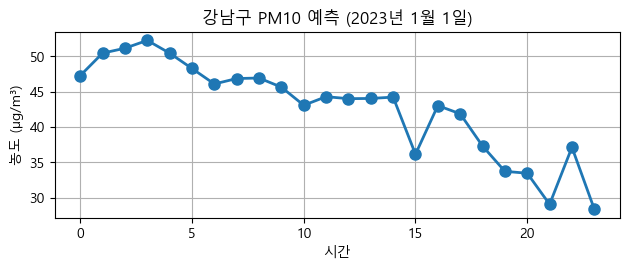

In [93]:
# PM10 그래프
plt.subplot(2, 1, 1)
plt.plot(range(24), pm10_predictions, marker='o', linewidth=2, markersize=8)
plt.title(f'{selected_area} PM10 예측 (2023년 1월 1일)')
plt.xlabel('시간')
plt.ylabel('농도 (μg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 사전설치 : pip install xgboost
## 컬럼명,설명  ##
# season,계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울). 범주형 데이터.
# holiday,공휴일 여부 (0: 공휴일 아님, 1: 공휴일). 이진(binary) 데이터.
# workingday,근무일 여부 (0: 근무일 아님 (주말 또는 공휴일), 1: 근무일). 이진(binary) 데이터.
# weather,날씨 상태 (1: 맑음, 약간 흐림; 2: 안개, 흐림; 3: 약한 눈/비, 천둥번개; 4: 폭우/폭설, 안개). 범주형 데이터.
# temp,정규화된 온도 (섭씨). 0과 1 사이로 스케일링된 값. 실제 온도를 얻으려면 이 값에 스케일링 인자를 곱해야 할 수 있음.
# atemp,정규화된 체감 온도 (섭씨). 0과 1 사이로 스케일링된 값. 체감 온도는 바람, 습도 등을 고려한 온도.
# humidity,정규화된 습도. 0과 1 사이로 스케일링된 값.
# windspeed,정규화된 풍속. 0과 1 사이로 스케일링된 값.
# casual,비등록 사용자(회원이 아닌 사용자)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# registered,등록 사용자(회원)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# count,총 자전거 대여 건수 (casual + registered). 숫자형 데이터. 이 데이터셋에서 주요 예측 목표 변수(target variable).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
df = pd.read_csv('dataset/bike.csv')
print("데이터 크기:", df.shape)

# 2. 간단한 전처리 및 새로운 피처 추가
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# 필요 없는 컬럼 제거
df = df.drop(['datetime', 'casual', 'registered'], axis=1)

# 로그 변환 (count가 편향되어 있으므로, 예로 특정시간대에는 많고, 새벽등 다른 시간대에는 적은 경우, 정규분포로 변환하여 모델학습 안정화)
df['count'] = np.log1p(df['count'])

# 3. X, y 분리
X = df.drop('count', axis=1)
y = df['count']

# 4. 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 표준화 (XGBoost에는 꼭 필요는 없지만 예시로 포함)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 하이퍼파라미터 튜닝: GridSearchCV
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)   # 제곱오차(reg:squarederror)로 MSE를 뜻함

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],   # 각 트리 학습에 사용되는 데이터 샘플 비율, 과적합 방지
    'colsample_bytree': [0.8, 1],   # 각 트리에서 사용되는 피처(변수)의 비율, 과적합 방지
    'alpha': [0, 1],   # L1 정규화 (0: L1정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
    'lambda': [1, 10]  # L2 정규화 (0: L2정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # GridSearchCV는 점수가 높을수록 좋은 모델로 간주함으로 RMSE에 negative(-)가 붙어서 덜 음수인 값이 더 나은 모델로 평가되도록 함
    cv=3,
    verbose=1,
    n_jobs=-1  # (n_jobs=1: 병렬처리 없이 단일 CPU코어로 순차적 학습, n_jobs=n: n개의 CPU코어로 사용, n_jobs=-1: 모든 CPU코어 사용)
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# 7. 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 역변환 (log1p → 원래 값)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

# 8. 평가
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# 9. 피처 중요도 시각화
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # argsort: 오름차순으로 정렬했을 때의 인덱스를 반환, [::-1}: 중요도 내림차순 정렬
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features
)
plt.title("Feature Importances (XGBoost) - Sorted")
plt.show()

# 10. 예측 vs 실제 시각화
plt.figure(figsize=(8, 5))
plt.plot(y_test_exp.values[:100], label="Actual")  # 테스트 데이터의 첫 100개 샘플만 시각화
plt.plot(y_pred_exp[:100], label="Predicted") # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Prediction vs Actual (first 100)")
plt.xlabel("Sample")
plt.ylabel("Bike Count")
plt.show()
